In [2]:
from idlelib.configdialog import font_sample_text

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from scipy.stats import linregress

In [82]:
def gaussienne(x,x0,A,w,bruit):
    return A*np.exp(-(x-x0)**2/w**2) +bruit

In [148]:
def sinus(ang,A,off,phi):
    theta_rad = np.radians(ang-phi)
    return A*np.sin(theta_rad)**2+off

In [122]:
def sinus2(ang,A,off,phi):
    theta_rad = np.radians(ang-phi)
    return A*np.sin(2*theta_rad)**2+off

LinregressResult(slope=np.float64(0.04316519245020272), intercept=np.float64(-8.118496059462867), rvalue=np.float64(0.99612654212182), pvalue=np.float64(4.093301082455863e-31), stderr=np.float64(0.0007200847395534107), intercept_stderr=np.float64(0.24218481345584655))


np.float64(180.0)

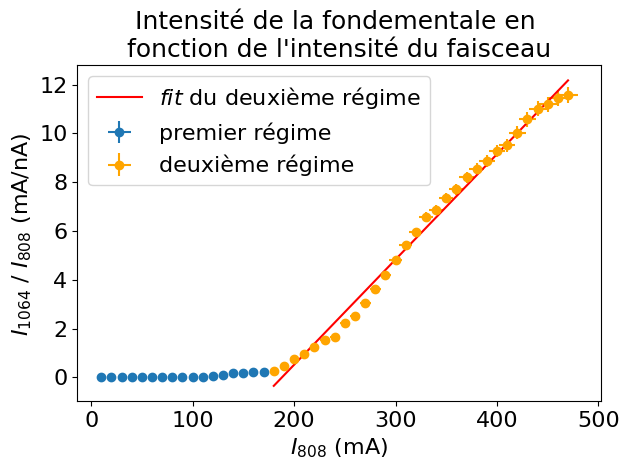

In [266]:
#I1064 selon I808

ratio = np.loadtxt('donnees\\i808i1064')
I808 = ratio.T[0][1:]*1e3
I1064 = ratio.T[1][1:]*1e9
bruit = ratio.T[1][0]*1e9

I808err = I808/50 #erreur d'environ 2%
Yerr = np.sqrt((I1064/50/I808)**2 + ((I1064-bruit)/I808**2*I808err)**2)
p1regime = np.where(np.gradient(I1064)<10)[0]
plt.errorbar(I808[p1regime], ((I1064-bruit)/I808)[p1regime],xerr=I808err[p1regime],yerr=Yerr[p1regime],label='premier régime',ls='',marker='o')

p2regime = np.where(np.gradient(I1064)>10)[0]
droiteX = I808[p2regime]
droiteY = I1064[p2regime]/I808[p2regime]

plt.errorbar(droiteX,droiteY,xerr=I808err[p2regime],yerr=Yerr[p2regime],label='deuxième régime',color='orange',ls='',marker='o')

regimeLigne = linregress(droiteX,droiteY)
plt.plot(droiteX,regimeLigne.slope*droiteX+regimeLigne.intercept, color='red',label=r'$\it{fit}$ du deuxième régime')
plt.xlabel(r'$I_{808}$ (mA)',fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel(r'$I_{1064}$ / $I_{808}$ (mA/nA) ',fontsize=16)
plt.yticks(fontsize=16)
plt.title('Intensité de la fondementale en \nfonction de l\'intensité du faisceau',fontsize=18)
plt.legend(loc='upper left',fontsize=16)
plt.tight_layout()
plt.savefig('donnees\\graphes\\courbe1')
print(regimeLigne)

#np.gradient(I1064)
droiteX[0]

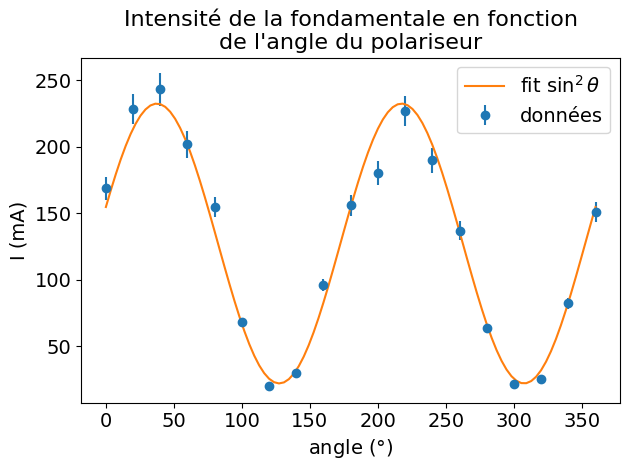

[2.10378371e-07 2.19238206e-08 1.27435496e+02] [[ 6.76703586e-17 -3.42584372e-17  2.22555228e-10]
 [-3.42584372e-17  2.54494462e-17  1.01903104e-10]
 [ 2.22555228e-10  1.01903104e-10  1.15092066e+00]]


In [157]:
pol = np.loadtxt('donnees\\polarisation')
degrés = (pol.T[0])
intensité = pol.T[1]

varint = intensité/20 # la valeur sur le pico ampèremêtre pouvait varier en général jusqu'à 5%


A0 = max(intensité) - min(intensité)
off0 = min(intensité)
phi0 = 40
p = [A0,off0,phi0]

popt_ang,pcov_ang = curve_fit(sinus,degrés,intensité,p0=p,bounds=([0, -360, 0], [np.inf, 360, np.inf]))
angtheo = np.linspace(0,360,100)

plt.errorbar(degrés,(intensité)*1e9,linestyle='',marker='o',yerr=varint*1e9,label='données')
plt.plot(angtheo,sinus(angtheo,*popt_ang)*1e09,label=r'fit $\sin^2{\theta}$')

plt.xlabel(r'angle ($\degree$)',fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel(r'I (mA)',fontsize=14)
plt.yticks(fontsize=14)
plt.title('Intensité de la fondamentale en fonction\nde l\'angle du polariseur',fontsize=16)
plt.legend(loc='upper right',fontsize=14)
plt.tight_layout()
plt.savefig('donnees\\graphes\\IvsPol')
plt.show()
print(popt_ang,pcov_ang)

[   0    1    2 ... 1131 1132 1133]
Pour la fondamentale : x0= 1065.266,I= 21631.607939073925,w= 0.647558076819382, bruit= 1291.035011400145
Pour la fondamentale : x0= 1065.266,I= 21631.607939073925,w= 0.647558076819382, bruit= 1291.035011400145
0.008108755281436349 0.011623518270730602


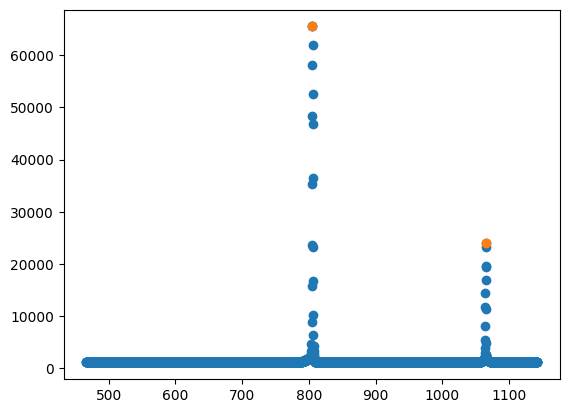

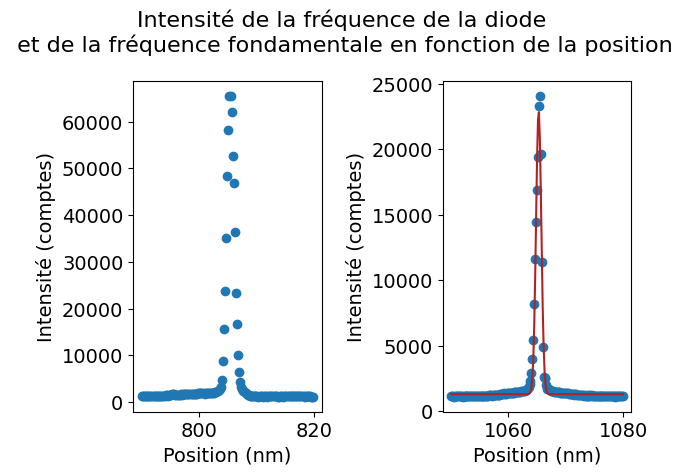

<Figure size 640x480 with 0 Axes>

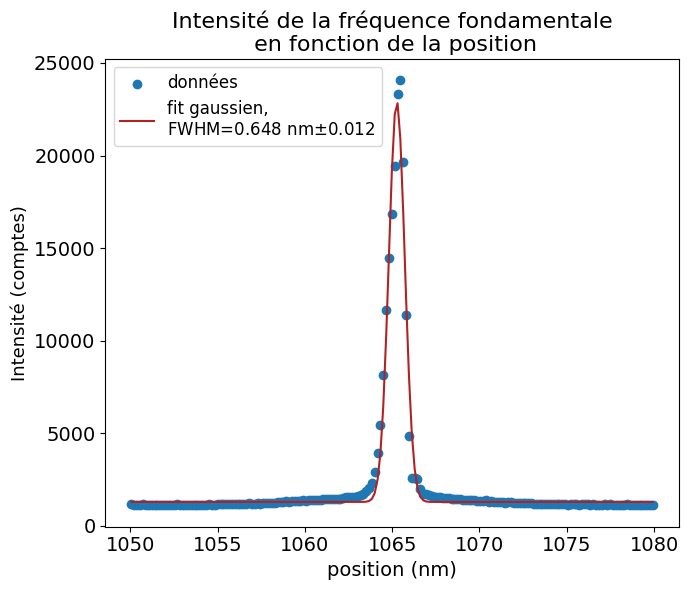

In [292]:
Ilambd = np.loadtxt('donnees\\ilambd250mA.txt')
position = Ilambd.T[0]
itensité = Ilambd.T[1]

plt.scatter(position,itensité)

peaks = find_peaks(itensité,height= 20000)[0]

position1064 = position[np.where( (position >1050) & (position < 1080) )[0]]
itensité1064 = itensité[np.where( (position >1050) & (position < 1080) )[0]]

print(np.where( (position>400) & (position < 700))[0] )

popt_las,pcov_las = curve_fit(gaussienne,position1064,itensité1064,p0=p01064)
print('Pour la fondamentale : x0= {:.3f},I= {},w= {}, bruit= {}'.format(*popt_las))

plt.scatter(position[peaks],itensité[peaks])

fig,ax = plt.subplots(1,2)

plt.figure()
fig.suptitle('Intensité de la fréquence de la diode\n et de la fréquence fondamentale en fonction de la position',fontsize=16)
ax[0].scatter(position[np.where( (position >790) & (position < 820) )[0]],itensité[np.where( (position >790) & (position < 820) )[0]])

#ax[0].set_title('Intensité de la fréquence de la diode\n en fonction de la position',fontsize=16)
ax[0].set_ylabel('Intensité (comptes)',fontsize=14)
ax[1].set_ylabel('Intensité (comptes)',fontsize=14)
ax[0].set_xlabel('Position (nm)',fontsize=14)
ax[1].set_xlabel('Position (nm)',fontsize=14)
ax[0].tick_params(labelsize=14)
ax[1].tick_params(labelsize=14)

#ax[1].set_title('Intensité de la fréquence fondamentale\n en fonction de la position',fontsize=16)
ax[1].scatter(position1064,itensité1064,label='données')
ax[1].plot(position1064,gaussienne(position1064,*popt_las),color='firebrick',label=f'fit gaussien,\nFWHM={popt_las[2]:.3f} nm'+r'$\pm$'+f'{np.sqrt(pcov_las[2,2]):.3f}')
fig.tight_layout()
fig.savefig('donnees\\graphes\\les2')

plt.figure(figsize=(7,6))
plt.scatter(position1064,itensité1064,label='données')
#trouvons la largeur à mi-hauteur du laser
x0_0 = position1064[np.where(itensité1064 == max(itensité1064))][0]
A0 = itensité1064[np.where(itensité1064 == max(itensité1064))][0]
w0 = 2
bruit0 = itensité1064[0]

p01064 = [x0_0,A0,w0,bruit0]

popt_las,pcov_las = curve_fit(gaussienne,position1064,itensité1064,p0=p01064)
print('Pour la fondamentale : x0= {:.3f},I= {},w= {}, bruit= {}'.format(*popt_las))
plt.plot(position1064,gaussienne(position1064,*popt_las),color='firebrick',label=f'fit gaussien,\nFWHM={popt_las[2]:.3f} nm'+r'$\pm$'+f'{np.sqrt(pcov_las[2,2]):.3f}')
plt.ylabel('Intensité (comptes)',fontsize=13)
plt.xticks(fontsize=14)
plt.xlabel('position (nm)',fontsize=14)
plt.yticks(fontsize=14)
plt.title('Intensité de la fréquence fondamentale\n en fonction de la position',fontsize=16)
plt.legend(loc='upper left',fontsize=12)
plt.tight_layout()
plt.savefig('donnees\\graphes\\pic1064')
print(np.sqrt(pcov_las[0,0]),np.sqrt(pcov_las[2,2]))



CRÉATION DE 2IEME HARMONIQUE

LinregressResult(slope=np.float64(0.9617374285548776), intercept=np.float64(-5.357615558766861), rvalue=np.float64(0.9989513017547881), pvalue=np.float64(2.59109250554239e-32), stderr=np.float64(0.009191251726926601), intercept_stderr=np.float64(0.10687566488446798))

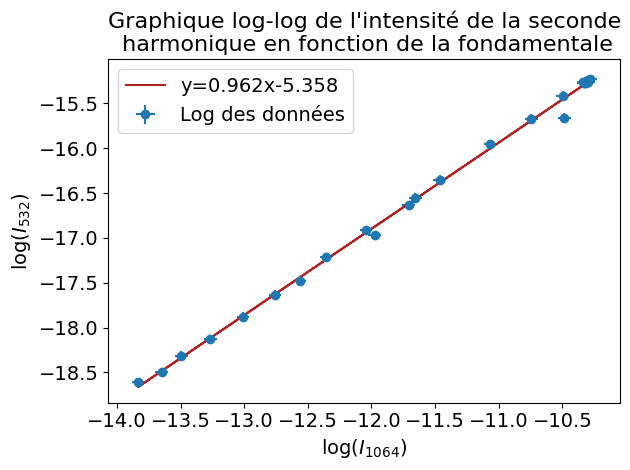

In [227]:
harmonique2 = np.loadtxt('donnees\\harmoniqueNo2').T
I1er = (harmonique2[0])
I2eme = (harmonique2[1])

I1err = I1er/20/I1er #suit la fonction log(I)
I2err = I2eme/20/I2eme


plt.errorbar(np.log(I1er),np.log(I2eme),ls='',marker='o',xerr=I1err,yerr=I2err,label='Log des données')
courbeHar2 = linregress(np.log(I1er),np.log(I2eme))
plt.plot(np.log(I1er),(courbeHar2.slope*np.log(I1er)+courbeHar2.intercept),color='firebrick',label=f'y={courbeHar2.slope:.3f}x{courbeHar2.intercept:.3f}')
plt.xlabel(r'log($I_{1064}$)',fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel(r'log($I_{532}$)',fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.title('Graphique log-log de l\'intensité de la seconde\n harmonique en fonction de la fondamentale',fontsize=16)
plt.tight_layout()
plt.savefig('donnees\\graphes\\harmonique2')
courbeHar2


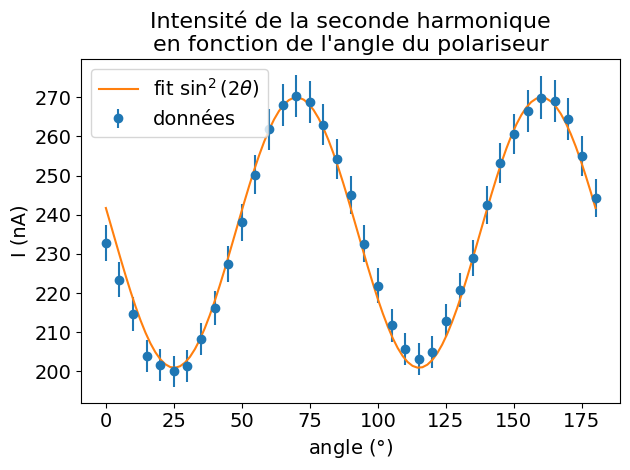

In [228]:
polarisationHar2 = np.loadtxt('donnees\\polarisation2har').T
angles = polarisationHar2[0].T
ipol = polarisationHar2[1].T*1e9

varipol = ipol/50 #les données variant d'environ 2%

A02 = max(ipol) - min(ipol)
off02 = min(ipol)
phi02 = 10
p2 = [A02,off02,phi02]

angtheo2 = np.linspace(0,180,100)

popt_ang2,pcov_ang2 = curve_fit(sinus2,angles,ipol,p0=p2,bounds=([0, -360, 0], [np.inf, 360, np.inf]))

plt.errorbar(angles,ipol,yerr=varipol,ls='',marker='o',label='données')
plt.plot(angtheo2,sinus2(angtheo2,*popt_ang2),label=r'fit $\sin^2{(2\theta)}$')
plt.xlabel(r'angle ($\degree$)',fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel(r'I (nA)',fontsize=14)
plt.yticks(fontsize=14)
plt.title('Intensité de la seconde harmonique\nen fonction de l\'angle du polariseur',fontsize=16)
plt.legend(loc ='upper left',fontsize=14)
plt.tight_layout()
plt.tight_layout()
plt.savefig('donnees\\graphes\\I2vsPol')
